In [77]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint as sp_randint

import shap
import joblib

In [78]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

# Data Loading and Inspection

In [79]:
df_gym= pd.read_csv('data/1. Gym Members Exercise Dataset/gym_members_exercise_tracking.csv')
df_fit = pd.read_csv('data/2. Exercise and Fitness Metrics Dataset/exercise_dataset.csv')
df_excise= pd.read_csv('data/3. Fitness Exercises Dataset/exercises_flat.csv')
df_rec = pd.read_excel('data/4. Mendeley Gym Recommendation Dataset/gym recommendation.xlsx')

print("Columns in gym_members_exercise_tracking.csv:", df_gym.columns.tolist())
print("Columns in exercise_dataset.csv:", df_fit.columns.tolist())
print("Columns in exercises_flat.csv:", df_excise.columns.tolist())
print("Columns in gym recommendation.xlsx:", df_rec.columns.tolist())
print()
print(f'Dataset 1 (Gym Members)          : {df_gym.shape[0]:,} rows × {df_gym.shape[1]} cols')
print(f'Dataset 2 (Exercise & Fitness)   : {df_fit.shape[0]:,} rows × {df_fit.shape[1]} cols')
print(f'Dataset 3 (Exercise Library)     : {df_excise.shape[0]:,} rows × {df_excise.shape[1]} cols')
print(f'Dataset 4 (Mendeley Coaching)    : {df_rec.shape[0]:,} rows × {df_rec.shape[1]} cols')
print()

Columns in gym_members_exercise_tracking.csv: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']
Columns in exercise_dataset.csv: ['ID', 'Exercise', 'Calories Burn', 'Dream Weight', 'Actual Weight', 'Age', 'Gender', 'Duration', 'Heart Rate', 'BMI', 'Weather Conditions', 'Exercise Intensity']
Columns in exercises_flat.csv: ['exerciseId', 'name', 'gifUrl', 'target_muscles', 'body_part_category', 'equipment_needed', 'secondaryMuscles', 'instructions']
Columns in gym recommendation.xlsx: ['ID', 'Sex', 'Age', 'Height', 'Weight', 'Hypertension', 'Diabetes', 'BMI', 'Level', 'Fitness Goal', 'Fitness Type', 'Exercises', 'Equipment', 'Diet', 'Recommendation']

Dataset 1 (Gym Members)          : 973 rows × 15 cols
Dataset 2 (Exercise & Fitness)   : 3,864 rows × 12 cols
Dataset 3 (Exercise Library)    

In [80]:
print(df_gym.head(3).to_string())
print(df_fit.head(3).to_string())
print(df_excise.head(3).to_string())
print(df_rec.head(3).to_string())


   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level    BMI
0   56    Male         88.3        1.71      180      157           60                      1.69           1313.0         Yoga            12.6                    3.5                              4                 3  30.20
1   46  Female         74.9        1.53      179      151           66                      1.30            883.0         HIIT            33.9                    2.1                              4                 2  32.00
2   32  Female         68.1        1.66      167      122           54                      1.11            677.0       Cardio            33.4                    2.3                              4                 2  24.71
   ID    Exercise  Calories Burn  Dream Weight  Actual Weight  Age Gender  Duration  Heart Rate        BMI Weath

In [81]:
for label, df in [("D1 Gym Members", df_gym), ("D2 Fitness", df_fit),("D3 Exercises", df_excise), ("D4 Recommendation", df_rec)]:
    missing = df.isnull().sum()
    has_missing = missing[missing > 0]
    if len(has_missing):
        print(f"\n{label}:\n{has_missing}")
    else:
        print(f"{label}: No missing values")

D1 Gym Members: No missing values
D2 Fitness: No missing values
D3 Exercises: No missing values
D4 Recommendation: No missing values


In [82]:
print("\nDataset 1 (Gym Members) Descriptive Stats")
print(df_gym.describe().round(2).to_string())
 
print("\nDataset 2 (Fitness) Descriptive Stats")
print(df_fit.describe().round(2).to_string())

print("\nDataset 3 (Exercises) Descriptive Stats")
print(df_excise.describe().round(2).to_string())

print("\nDataset 4 (Recommendation) Descriptive Stats")
print(df_rec.describe().round(2).to_string())


Dataset 1 (Gym Members) Descriptive Stats
          Age  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  Session_Duration (hours)  Calories_Burned  Fat_Percentage  Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level     BMI
count  973.00       973.00      973.00   973.00   973.00       973.00                    973.00           973.00          973.00                 973.00                         973.00            973.00  973.00
mean    38.68        73.85        1.72   179.88   143.77        62.22                      1.26           905.42           24.98                   2.63                           3.32              1.81   24.91
std     12.18        21.21        0.13    11.53    14.35         7.33                      0.34           272.64            6.26                   0.60                           0.91              0.74    6.66
min     18.00        40.00        1.50   160.00   120.00        50.00                      0.50           303.00         

In [83]:
print("Dataset 1 (Gym Members) Info:")
df_gym.info()

print("\nDataset 2 (Fitness) Info:")
df_fit.info()

print("\nDataset 3 (Exercises) Info:")
df_excise.info()

print("\nDataset 4 (Recommendation) Info:")
df_rec.info()

Dataset 1 (Gym Members) Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (d

In [84]:
df_gym.head(3)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71


In [85]:
df_gym.head(3)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71


In [86]:
df_excise.head(3)

,exerciseId,name,gifUrl,target_muscles,body_part_category,equipment_needed,secondaryMuscles,instructions
0,2ORFMoR,hack calf raise,2ORFMoR.gif,calves,lower legs,sled machine,hamstrings; glutes,Step:1 Adjust the sled machine to a comfortabl...
1,2Qh2J1e,sled 45Â° leg press (side pov),2Qh2J1e.gif,glutes,upper legs,sled machine,quadriceps; hamstrings; calves,Step:1 Adjust the seat of the sled machine so ...
2,3eGE2JC,dumbbell front raise,3eGE2JC.gif,delts,shoulders,dumbbell,biceps; trapezius,Step:1 Stand with your feet shoulder-width apa...


In [87]:
df_rec.head(3)

,ID,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal,Fitness Type,Exercises,Equipment,Diet,Recommendation
0,1,Male,18,1.68,47.5,No,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, and Lettuc...",Follow a regular exercise schedule. Adhere to ...
1,2,Male,18,1.68,47.5,Yes,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...","Light athletic shoes, resistance bands, and li...","Vegetables: (Tomatoes, Garlic, leafy greens, b...",Follow a regular exercise schedule. Adhere to ...
2,3,Male,18,1.68,47.5,No,Yes,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, yoga, deadlifts, bench presses, and ov...","Dumbbells, barbells and Blood glucose monitor","Vegetables: (Garlic, Roma Tomatoes, Capers and...",Follow a regular exercise schedule. Adhere to ...


# Data Preprocessing

In [88]:
df_fit_clean = df_fit.copy()

df_fit_clean.drop(columns=['ID', 'Exercise'], inplace=True)

df_fit_clean.rename(columns={
    'Calories Burn' : 'Calories_Burned',
    'Actual Weight' : 'Weight (kg)',
    'Dream Weight' : 'Dream_Weight',
    'Heart Rate' : 'Avg_BPM',
    'Weather Conditions' : 'Weather_Conditions',
    'Exercise Intensity' : 'Exercise_Intensity',
}, inplace=True)

df_fit_clean.rename(columns={'Duration': 'Session_Duration (hours)'}, inplace=True)
df_fit_clean['Session_Duration (hours)'] = df_fit_clean['Session_Duration (hours)'] / 60

#Adding new column name _source to dataset 1 and 2 to identify the source of data
df_gym['_source']      = 'ds1'
df_fit_clean['_source'] = 'ds2'

In [89]:
print('DS1 columns:', list(df_gym.columns))
print()
print('DS2 columns After CLeaning and Renaming:', list(df_fit_clean.columns))

DS1 columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', '_source']

DS2 columns After CLeaning and Renaming: ['Calories_Burned', 'Dream_Weight', 'Weight (kg)', 'Age', 'Gender', 'Session_Duration (hours)', 'Avg_BPM', 'BMI', 'Weather_Conditions', 'Exercise_Intensity', '_source']


In [90]:
# pd.concat fills missing columns with NaN automatically
dfUnified = pd.concat([df_gym, df_fit_clean], ignore_index=True)

print(f'Merged DataFrame shape: {dfUnified.shape}')
print(f'  DS1 (gym data) rows: {(dfUnified["_source"]=="ds1").sum()}')
print(f'  DS2 (fit data) rows: {(dfUnified["_source"]=="ds2").sum()}')
print()
print('Missing values per column:')
print(dfUnified.isnull().sum().to_string())

Merged DataFrame shape: (4837, 19)
  DS1 (gym data) rows: 973
  DS2 (fit data) rows: 3864

Missing values per column:
Age                                 0
Gender                              0
Weight (kg)                         0
Height (m)                       3864
Max_BPM                          3864
Avg_BPM                             0
Resting_BPM                      3864
Session_Duration (hours)            0
Calories_Burned                     0
Workout_Type                     3864
Fat_Percentage                   3864
Water_Intake (liters)            3864
Workout_Frequency (days/week)    3864
Experience_Level                 3864
BMI                                 0
_source                             0
Dream_Weight                      973
Weather_Conditions                973
Exercise_Intensity                973


In [91]:
dfUnified.head(3)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,_source,Dream_Weight,Weather_Conditions,Exercise_Intensity
0,56,Male,88.3,1.71,180.0,157,60.0,1.69,1313.0,Yoga,12.6,3.5,4.0,3.0,30.20,ds1,NaN,NaN,NaN
1,46,Female,74.9,1.53,179.0,151,66.0,1.30,883.0,HIIT,33.9,2.1,4.0,2.0,32.00,ds1,NaN,NaN,NaN
2,32,Female,68.1,1.66,167.0,122,54.0,1.11,677.0,Cardio,33.4,2.3,4.0,2.0,24.71,ds1,NaN,NaN,NaN


In [92]:
#Training Random Forest Regressor for each column using dataset one then predict realistic values for dataset two

IMPUTE_PREDICTORS = [
    'Age', 'Weight (kg)', 'BMI',
    'Avg_BPM', 'Session_Duration (hours)'
]

# Encode Gender temporarily just for imputation models
dfUnified['_g'] = (dfUnified['Gender'] == 'Male').astype(int)
imp_preds = IMPUTE_PREDICTORS + ['_g']

ds1_mask = dfUnified['_source'] == 'ds1'
ds2_mask = dfUnified['_source'] == 'ds2'

NUMERIC_IMPUTE_COLS = [
    'Height (m)', 'Max_BPM', 'Resting_BPM',
    'Fat_Percentage', 'Water_Intake (liters)',
    'Workout_Frequency (days/week)', 'Experience_Level'
]

imputer_models = {}   # save each model (needed to impute inference-time data)
impute_report = []

print('Training Random Forest imputers (per missing column):\n')
for col in NUMERIC_IMPUTE_COLS:
    missing_n = dfUnified[col].isnull().sum()
    if missing_n == 0:
        print(f'  {col:<42s} — no missing values, skipped')
        continue

    X_known = dfUnified.loc[ds1_mask, imp_preds]
    y_known = dfUnified.loc[ds1_mask, col]

    imp_rf = RandomForestRegressor(
        n_estimators=200, max_depth=10,
        random_state=42, n_jobs=-1
    )
    imp_rf.fit(X_known, y_known)

    train_r2 = imp_rf.score(X_known, y_known)

    # CV R² on DS1 data just a sanity check (not a real estimate of imputation quality, but better than nothing) hekps to identify overfitting imputation models
    cv_r2 = cross_val_score(
        imp_rf, X_known, y_known,
        cv=5, scoring='r2', n_jobs=-1
    ).mean()

    X_missing = dfUnified.loc[ds2_mask, imp_preds]
    dfUnified.loc[ds2_mask, col] = imp_rf.predict(X_missing)

    imputer_models[col] = imp_rf
    impute_report.append({'Column': col, 'Missing': missing_n,
                          'Train R²': round(train_r2, 3),
                          'CV R² (5-fold)': round(cv_r2, 3)})
    print(f'  {col:<42s} Train R²={train_r2:.3f}  CV R²={cv_r2:.3f}')

dfUnified.drop(columns=['_g'], inplace=True)

print()
print(pd.DataFrame(impute_report).to_string(index=False))
print(f'\nRemaining numeric NaNs: {dfUnified.select_dtypes(include="number").isnull().sum().sum()}')

Training Random Forest imputers (per missing column):



  Height (m)                                 Train R²=0.996  CV R²=0.970
  Max_BPM                                    Train R²=0.557  CV R²=-0.074
  Resting_BPM                                Train R²=0.526  CV R²=-0.033
  Fat_Percentage                             Train R²=0.925  CV R²=0.794
  Water_Intake (liters)                      Train R²=0.843  CV R²=0.574
  Workout_Frequency (days/week)              Train R²=0.801  CV R²=0.470
  Experience_Level                           Train R²=0.875  CV R²=0.731

                       Column  Missing  Train R²  CV R² (5-fold)
                   Height (m)     3864     0.996           0.970
                      Max_BPM     3864     0.557          -0.074
                  Resting_BPM     3864     0.526          -0.033
               Fat_Percentage     3864     0.925           0.794
        Water_Intake (liters)     3864     0.843           0.574
Workout_Frequency (days/week)     3864     0.801           0.470
             Experience_Level  

In [93]:
# Train a Random Forest classifier on the rows that HAVE the value,predict for rows that don't (predicting Gender for DS2 using DS1 data)

cat_report = []
def impute_categorical(col, train_mask, predict_mask, predictors):
    dfUnified['_g2'] = (dfUnified['Gender'] == 'Male').astype(int)
    feats = [p for p in predictors + ['_g2'] if p in dfUnified.columns]

    X_known  = dfUnified.loc[train_mask,   feats]
    y_known  = dfUnified.loc[train_mask,   col]
    X_miss   = dfUnified.loc[predict_mask, feats]

    clf = RandomForestClassifier(
        n_estimators=200, max_depth=8,
        random_state=42, n_jobs=-1
    )
    clf.fit(X_known, y_known)
    cv_acc = cross_val_score(
        clf, X_known, y_known,
        cv=5, scoring='accuracy', n_jobs=-1
    ).mean()
    dfUnified.loc[predict_mask, col] = clf.predict(X_miss)
    dfUnified.drop(columns=['_g2'], inplace=True)
    return clf, round(cv_acc, 3)

base_preds = [
    'Age', 'Weight (kg)', 'BMI',
    'Avg_BPM', 'Session_Duration (hours)'
]

# Workout_Type: train on DS1, predict for DS2
if dfUnified['Workout_Type'].isnull().sum() > 0:
    clf_wt, acc_wt = impute_categorical(
        'Workout_Type', ds1_mask, ds2_mask, base_preds
    )
    print(f'  Workout_Type      — CV Accuracy = {acc_wt:.3f}')
    cat_report.append({'Column': 'Workout_Type', 'CV Accuracy': acc_wt})

# Weather_Conditions: train on DS2, predict for DS1
if dfUnified['Weather_Conditions'].isnull().sum() > 0:
    clf_wc, acc_wc = impute_categorical(
        'Weather_Conditions', ds2_mask, ds1_mask,
        base_preds + ['Exercise_Intensity']
    )
    print(f'  Weather_Conditions — CV Accuracy = {acc_wc:.3f}')
    cat_report.append({'Column': 'Weather_Conditions', 'CV Accuracy': acc_wc})

print()
print(pd.DataFrame(cat_report).to_string(index=False))
print(f'\nRemaining categorical NaNs: {dfUnified[["Workout_Type","Weather_Conditions"]].isnull().sum().to_string()}')

  Workout_Type      — CV Accuracy = 0.246
  Weather_Conditions — CV Accuracy = 0.328

            Column  CV Accuracy
      Workout_Type        0.246
Weather_Conditions        0.328

Remaining categorical NaNs: Workout_Type          0
Weather_Conditions    0


In [94]:
dfUnified.drop(columns=['_source'], inplace=True)
print('Removed "_source" column. available columns:', list(dfUnified.columns))

print(f'\nRechecking NaNs: {dfUnified.isnull().sum().sum()}')

Removed "_source" column. available columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Dream_Weight', 'Weather_Conditions', 'Exercise_Intensity']

Rechecking NaNs: 1946


In [95]:
beforeLength = len(dfUnified)
dfUnified.drop_duplicates(inplace=True)
print('Duplicates removed:', beforeLength - len(dfUnified))

Duplicates removed: 0


In [96]:
Q1 = dfUnified['Calories_Burned'].quantile(0.25)
Q3 = dfUnified['Calories_Burned'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR

In [97]:
afterLength = len(dfUnified)
dfUnified = dfUnified[(dfUnified['Calories_Burned'] >= lower) & (dfUnified['Calories_Burned'] <= upper)]
print(f'Outliers removed: {afterLength - len(dfUnified)}')

Outliers removed: 136


In [98]:
print('Final Shape:', dfUnified.shape)

Final Shape: (4701, 18)


In [99]:
dfUnified['Gender'] = dfUnified['Gender'].map({'Male': 1, 'Female': 0}) #Male: 1, Female: 0

dfUnified = pd.get_dummies(dfUnified, columns=['Workout_Type'], prefix='wt', drop_first=False) #encoding for Workout_Type: wt_Cardio, wt_Strength, wt_Flexibility

weather_map = {'Sunny': 2, 'Cloudy': 1, 'Rainy': 0}
dfUnified['Weather_Conditions'] = dfUnified['Weather_Conditions'].map(weather_map)
dfUnified['Weather_Conditions'].fillna(dfUnified['Weather_Conditions'].median(), inplace=True) #Sunny=2, Cloudy=1, Rainy=0

bool_cols = dfUnified.select_dtypes(include='bool').columns
dfUnified[bool_cols] = dfUnified[bool_cols].astype(int) #convert bool into int (True=1, False=0) for wt_Cardio, wt_Strength, wt_Flexibility

In [100]:
print('Encoded columns:', [c for c in dfUnified.columns if c.startswith('wt_') or c in ['Gender','Weather_Conditions']])
print(f'DataFrame shape after encoding: {dfUnified.shape}')
dfUnified.head(3)

Encoded columns: ['Gender', 'Weather_Conditions', 'wt_Cardio', 'wt_HIIT', 'wt_Strength', 'wt_Yoga']
DataFrame shape after encoding: (4701, 21)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,...,Workout_Frequency (days/week),Experience_Level,BMI,Dream_Weight,Weather_Conditions,Exercise_Intensity,wt_Cardio,wt_HIIT,wt_Strength,wt_Yoga
1,46,0,74.9,1.53,179.0,151,66.0,1.30,883.0,33.9,...,4.0,2.0,32.00,NaN,1,NaN,0,1,0,0
2,32,0,68.1,1.66,167.0,122,54.0,1.11,677.0,33.4,...,4.0,2.0,24.71,NaN,1,NaN,1,0,0,0
3,25,1,53.2,1.70,190.0,164,56.0,0.59,532.0,28.8,...,3.0,1.0,18.41,NaN,1,NaN,0,0,1,0


In [101]:
dfUnified.columns.tolist()

['Age',
 'Gender',
 'Weight (kg)',
 'Height (m)',
 'Max_BPM',
 'Avg_BPM',
 'Resting_BPM',
 'Session_Duration (hours)',
 'Calories_Burned',
 'Fat_Percentage',
 'Water_Intake (liters)',
 'Workout_Frequency (days/week)',
 'Experience_Level',
 'BMI',
 'Dream_Weight',
 'Weather_Conditions',
 'Exercise_Intensity',
 'wt_Cardio',
 'wt_HIIT',
 'wt_Strength',
 'wt_Yoga']

In [102]:
dfUnified.dtypes

Age                                int64
Gender                             int64
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                          float64
Avg_BPM                            int64
Resting_BPM                      float64
Session_Duration (hours)         float64
Calories_Burned                  float64
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)    float64
Experience_Level                 float64
BMI                              float64
Dream_Weight                     float64
Weather_Conditions                 int64
Exercise_Intensity               float64
wt_Cardio                          int64
wt_HIIT                            int64
wt_Strength                        int64
wt_Yoga                            int64
dtype: object

# Feature Engineering

In [103]:
# HR × Duration: single strongest interaction term
dfUnified['HR_Duration'] = (
    dfUnified['Avg_BPM'] * dfUnified['Session_Duration (hours)']
)
# Workout intensity × time
dfUnified['Intensity_Duration'] = (
    dfUnified['Exercise_Intensity'] * dfUnified['Session_Duration (hours)']
)

# EDA

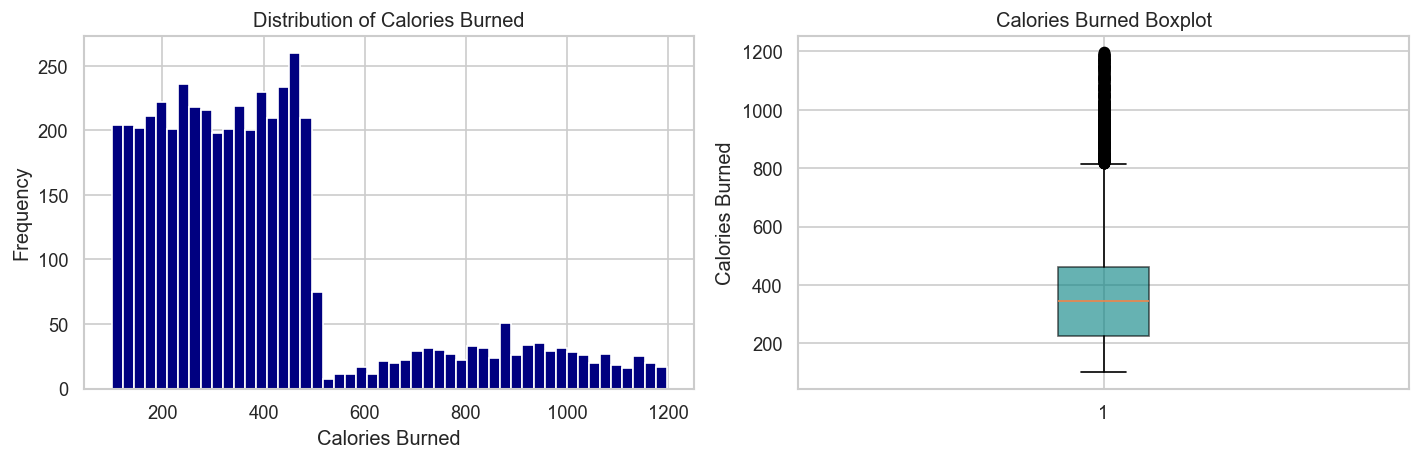

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dfUnified['Calories_Burned'], bins=50, color='navy', edgecolor='white')
axes[0].set_title('Distribution of Calories Burned')
axes[0].set_xlabel('Calories Burned')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(dfUnified['Calories_Burned'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.6))
axes[1].set_title('Calories Burned Boxplot')
axes[1].set_ylabel('Calories Burned')

plt.tight_layout()
plt.show()

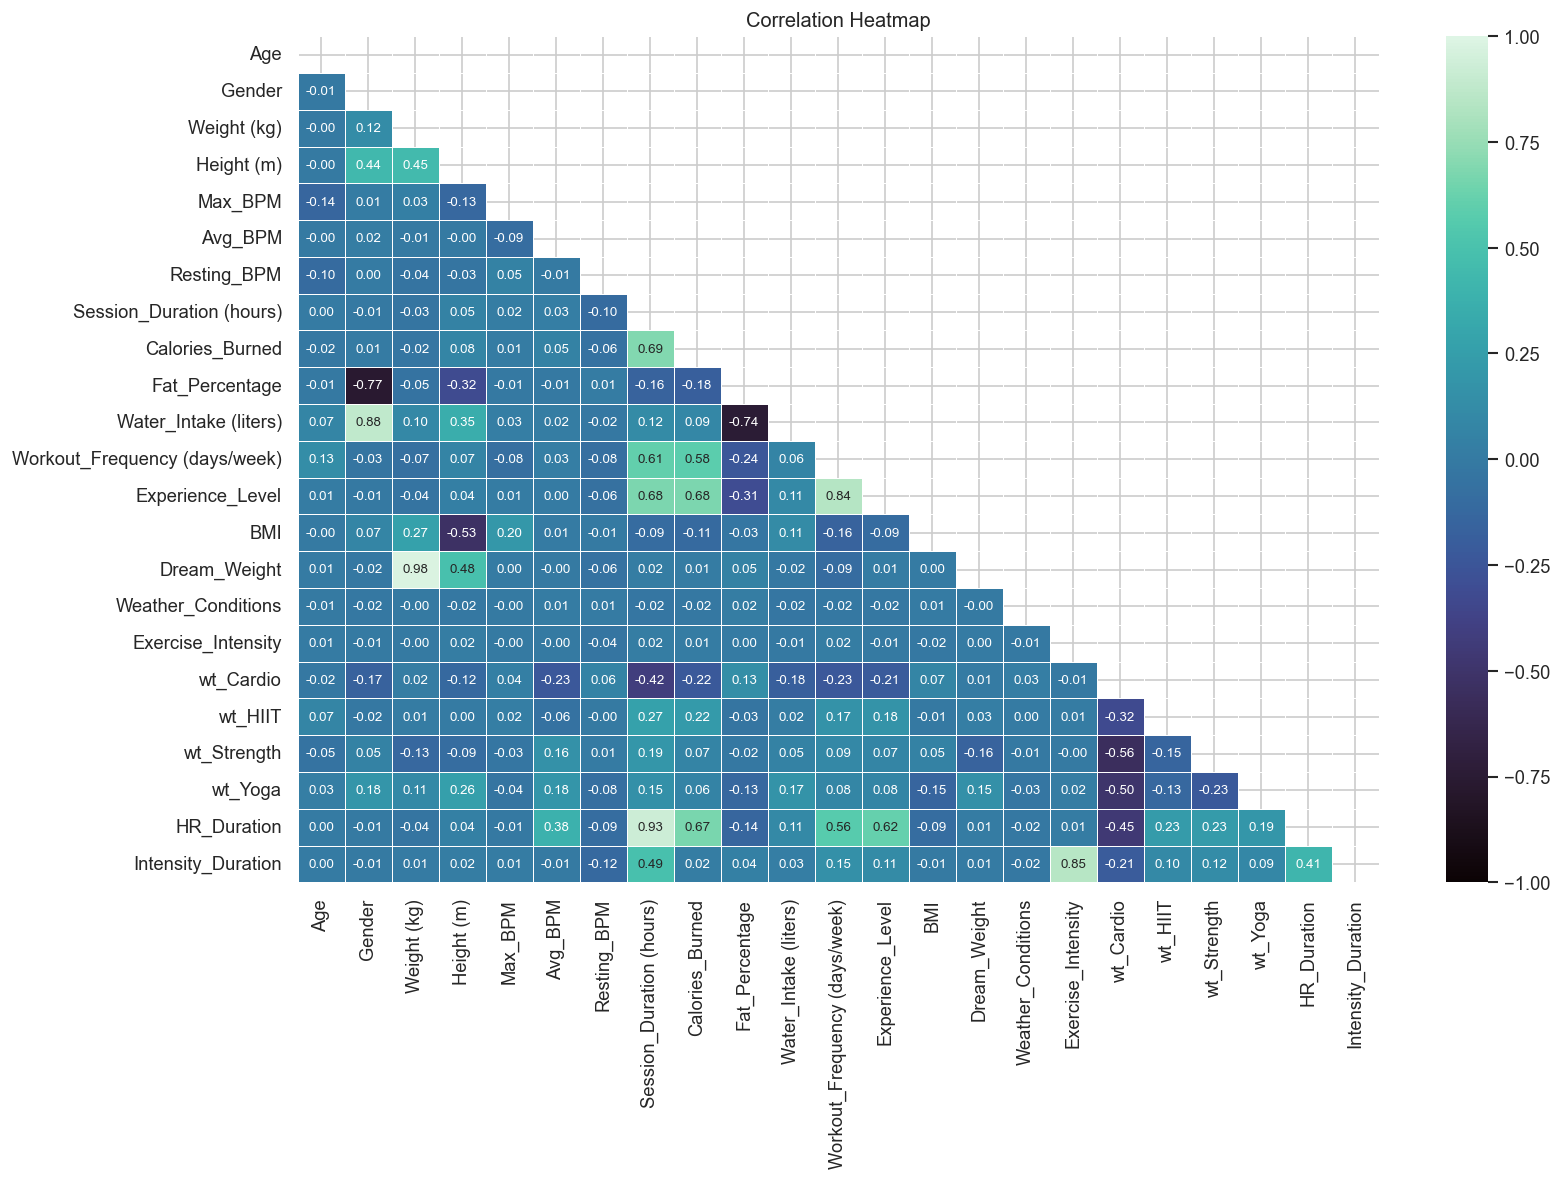

In [105]:
numeric_Df = dfUnified.select_dtypes(include='number')
corr = numeric_Df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='mako',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

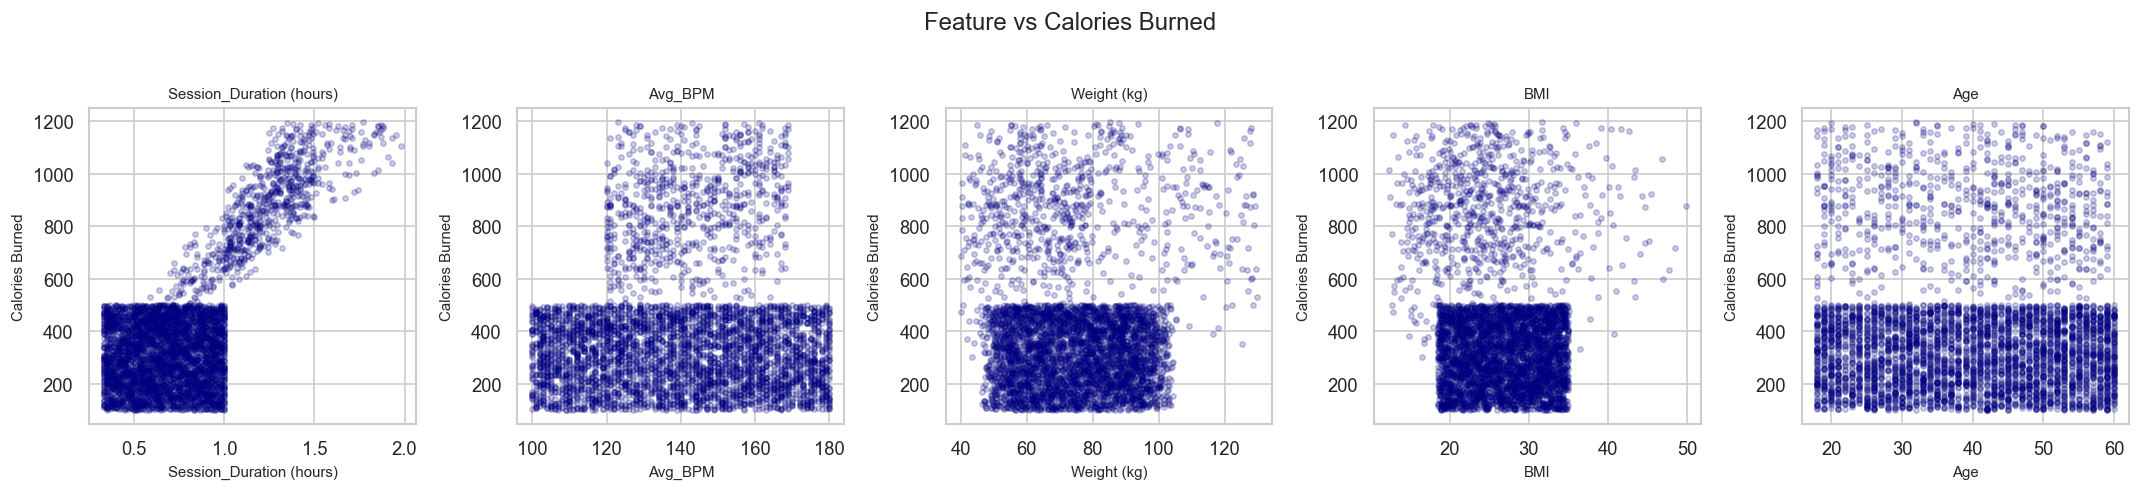

In [106]:
scatter_features = [
    'Session_Duration (hours)', 'Avg_BPM', 'Weight (kg)', 'BMI', 'Age'
]

fig, axes = plt.subplots(1, len(scatter_features), figsize=(18, 4))
for ax, feat in zip(axes, scatter_features):
    ax.scatter(dfUnified[feat], dfUnified['Calories_Burned'],
               alpha=0.2, s=10, color='navy')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Calories Burned', fontsize=9)
    ax.set_title(feat, fontsize=9)

plt.suptitle('Feature vs Calories Burned', y=1.02)
plt.tight_layout()
plt.show()

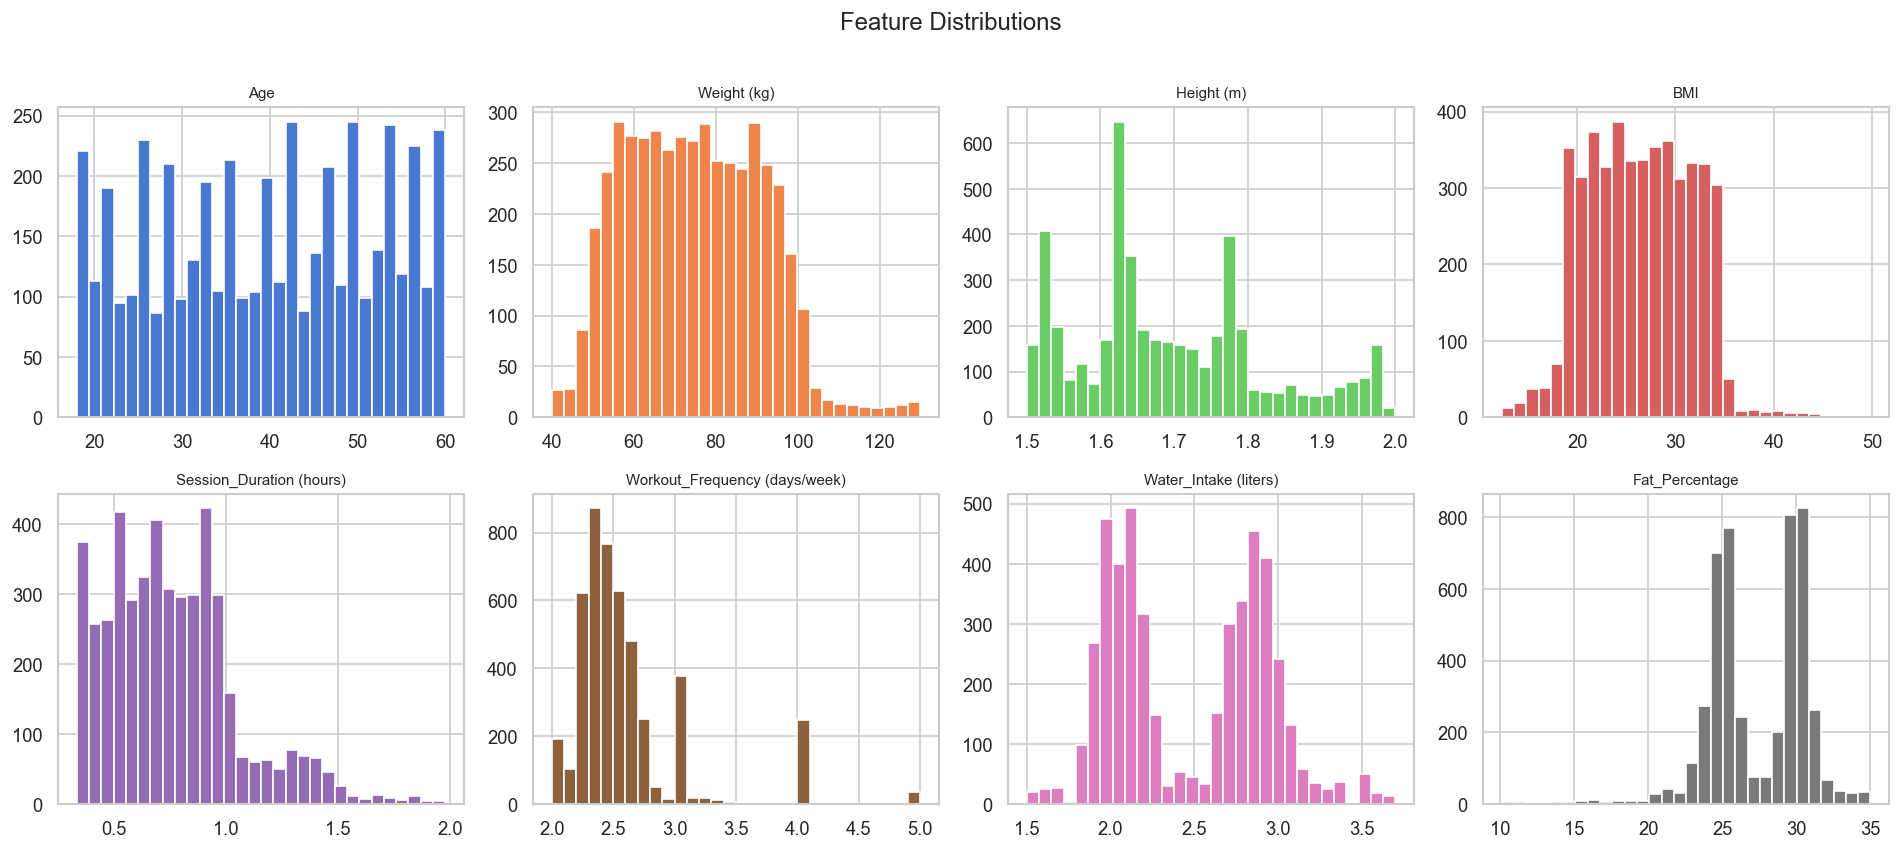

In [107]:
hist_features = ['Age', 'Weight (kg)', 'Height (m)', 'BMI',
                 'Session_Duration (hours)', 'Workout_Frequency (days/week)', 'Water_Intake (liters)', 'Fat_Percentage']
hist_features = [f for f in hist_features if f in dfUnified.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, feat in enumerate(hist_features):
    axes[i].hist(dfUnified[feat].dropna(), bins=30,
                 color=sns.color_palette('muted')[i % 8], edgecolor='white')
    axes[i].set_title(feat, fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

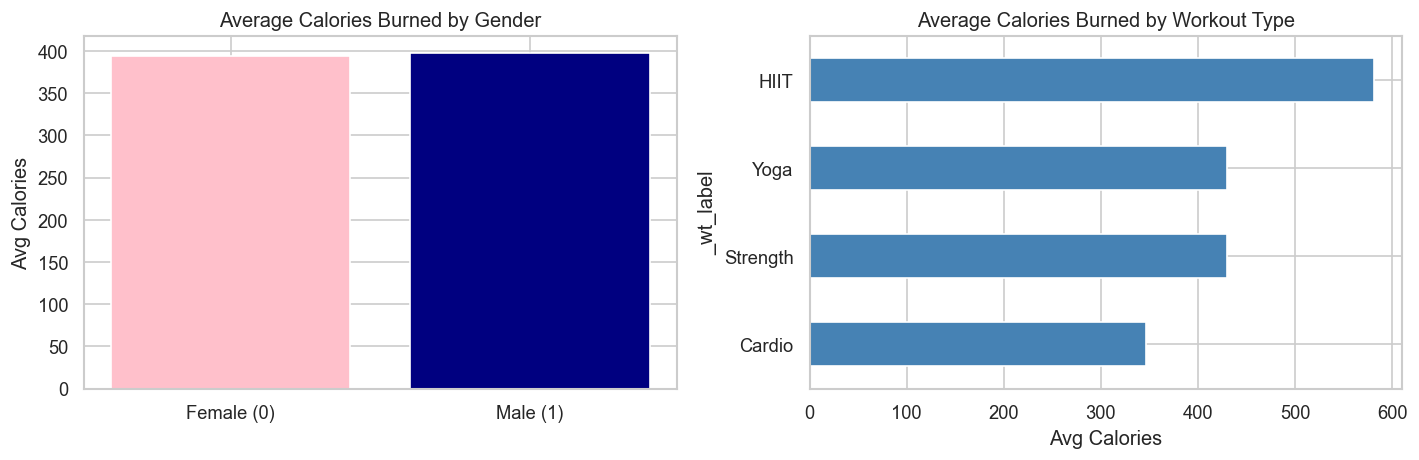

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_means = dfUnified.groupby('Gender')['Calories_Burned'].mean()
axes[0].bar(['Female (0)', 'Male (1)'], gender_means.values,
            color=['pink','navy'])
axes[0].set_title('Average Calories Burned by Gender')
axes[0].set_ylabel('Avg Calories')

wt_cols = [c for c in dfUnified.columns if c.startswith('wt_')]
if wt_cols:
    dfUnified['_wt_label'] = dfUnified[wt_cols].idxmax(axis=1).str.replace('wt_', '')
    wt_means = dfUnified.groupby('_wt_label')['Calories_Burned'].mean().sort_values()
    wt_means.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Average Calories Burned by Workout Type')
    axes[1].set_xlabel('Avg Calories')
    dfUnified.drop(columns=['_wt_label'], inplace=True)

plt.tight_layout()
plt.show()

# Feature Selection

In [109]:
#Multi method feature selection with statistical validity (Random Forest Importane[purity based, fast, can overfit], Permutation Importance [model agnostic, unbiased], Mutual Information [non parametric, captures non linear], SHAP values [game theoretic, most interpretable]) All four scores are normalized then average and features wuth Combined Score > 0.05 aare kept for model training

ALL_FEATURES = [c for c in dfUnified.columns if c != 'Calories_Burned']
X_fs = dfUnified[ALL_FEATURES].copy()
y_fs = dfUnified['Calories_Burned']

print('RF Importance: ')
rf_fs = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_fs.fit(X_fs, y_fs)
rf_imp = pd.Series(rf_fs.feature_importances_, index=ALL_FEATURES)

print('Permutation Importance: ')
perm = permutation_importance(
    rf_fs, X_fs, y_fs, n_repeats=15, random_state=42, n_jobs=-1
)
perm_imp = pd.Series(
    np.clip(perm.importances_mean, 0, None), index=ALL_FEATURES
)

print('Mutual Information: ')
mi = mutual_info_regression(X_fs, y_fs, random_state=42)
mi_imp = pd.Series(mi, index=ALL_FEATURES)

print('SHAP values: ')
shap_sample = X_fs.sample(min(800, len(X_fs)), random_state=42)
explainer = shap.TreeExplainer(rf_fs)
shap_vals = explainer.shap_values(shap_sample)
shap_imp = pd.Series(
    np.abs(shap_vals).mean(axis=0), index=ALL_FEATURES
)

def normalizeto01(s):
    rng = s.max() - s.min()
    return (s - s.min()) / (rng + 1e-12)

fs_scores = pd.DataFrame({
    'RF Importance'         : normalizeto01(rf_imp),
    'Permutation Importance': normalizeto01(perm_imp),
    'Mutual Information'    : normalizeto01(mi_imp),
    'SHAP'                  : normalizeto01(shap_imp),
})

fs_scores['Combined Score'] = fs_scores.mean(axis=1)
fs_scores = fs_scores.sort_values('Combined Score', ascending=False)

print()
print(fs_scores.round(3).to_string())

RF Importance: 
Permutation Importance: 
Mutual Information: 


ValueError: Input X contains NaN.

In [ ]:
THRESHOLD = 0.05
selected_features = fs_scores[fs_scores['Combined Score'] > THRESHOLD].index.tolist()

print(f'\n{len(selected_features)} features selected (combined score > {THRESHOLD}):')
print(selected_features)

In [ ]:
top_n = min(15, len(fs_scores))
top_feats = fs_scores.head(top_n)
methods = ['RF Importance', 'Permutation Importance', 'Mutual Information', 'SHAP']
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
colors = ['lightblue', 'teal', 'pink', 'yellow']
for ax, method, color in zip(axes, methods, colors):
    ax.barh(top_feats.index[::-1], top_feats[method][::-1], color=color)
    ax.set_title(method, fontsize=10)
    ax.set_xlabel('Normalized Score', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle('Feature Importance 4 Independent Methods', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
palette = ['#185FA5' if s > THRESHOLD else '#B4B2A9'
           for s in fs_scores['Combined Score']]
plt.barh(fs_scores.index[::-1], fs_scores['Combined Score'][::-1], color=palette[::-1])
plt.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'Threshold {THRESHOLD}')
plt.title('Combined Feature Score (avg of 4 methods)')
plt.xlabel('Combined Score (0-1)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
shap.summary_plot(
    shap_vals, shap_sample,
    feature_names=ALL_FEATURES,
    max_display=15, show=True
)

In [ ]:
X = dfUnified[selected_features].copy()
y = dfUnified['Calories_Burned'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling done. Train mean:', X_train_sc[:, :3].mean(axis=0).round(3))

# Training Model

In [ ]:
#Helper fn to evaluate models
results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te, use_scaled=False):
    Xtr = X_tr if not use_scaled else X_train_sc #train set (scaled)
    Xte = X_te if not use_scaled else X_test_sc #test set (scaled)

    pred = model.predict(Xte)  #predictions on test set
    mae  = mean_absolute_error(y_te, pred) #MAE on test set
    rmse = np.sqrt(mean_squared_error(y_te, pred)) #RMSE on test set
    r2   = r2_score(y_te, pred) #R² on test set
    
    # 5 fold cv R² on full scaled set
    cv_scores = cross_val_score(model, Xtr, y_tr, cv=5,
                                scoring='r2', n_jobs=-1)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2,
                     'CV_R2_mean': cv_scores.mean(), 'CV_R2_std': cv_scores.std()}
    
    print(f'  MAE  = {mae:.2f}')
    print(f'  RMSE = {rmse:.2f}')
    print(f'  R²   = {r2:.4f}')
    print(f'  CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    return pred

In [ ]:
print('Linear Regression:')
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
pred_lr = evaluate('Linear Regression', lr,
                   X_train_sc, X_test_sc, y_train, y_test,
                   use_scaled=True)

In [ ]:
print('Random Forest Regressor:')
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = evaluate('Random Forest', rf,
                   X_train, X_test, y_train, y_test)

In [ ]:
print('XG Boost Regressor:')
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)
pred_xgb = evaluate('XGBoost', xgb,
                    X_train, X_test, y_train, y_test)

In [ ]:
print('ANN:')

n_features = X_train_sc.shape[1]

ann = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

ann.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True
)

lr_sched = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

history = ann.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, lr_sched],
    verbose=0
)

pred_ann = ann.predict(X_test_sc).flatten()
mae_ann  = mean_absolute_error(y_test, pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, pred_ann))
r2_ann   = r2_score(y_test, pred_ann)

results['ANN'] = {'MAE': mae_ann, 'RMSE': rmse_ann, 'R2': r2_ann,
                  'CV_R2_mean': float('nan'), 'CV_R2_std': float('nan')}

print(f'  MAE  = {mae_ann:.2f}')
print(f'  RMSE = {rmse_ann:.2f}')
print(f'  R²   = {r2_ann:.4f}')
# Training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ANN Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

# Hyperparameter Tuning RF and XGB

In [ ]:
#RF Hyperparameter Tuning with RandomizedSearchCV (40 random combos, 5-fold CV, R² scoring) on the training set. Then evaluate the best RF model on the test set and compare CV R² with baseline RF to see if tuning helped

rf_param_dist = {
    'n_estimators'     : sp_randint(200, 800),
    'max_depth'        : [8, 10, 12, 15, 20, None],
    'min_samples_split': sp_randint(2, 12),
    'min_samples_leaf' : sp_randint(1, 6),
    'max_features'     : ['sqrt', 'log2', 0.4, 0.6],
    'bootstrap'        : [True, False],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)

print(f'Best Random Forest Parameters: {rf_search.best_params_}')
print(f'Best Cross Validation R²: {rf_search.best_score_:.4f}')

rf_tuned = rf_search.best_estimator_
pred_rf_tuned = evaluate(
    'RF (tuned)', rf_tuned,
    X_train, X_test, y_train, y_test
)

baseline_cv = results.get('Random Forest', {}).get('CV_R2_mean', 0)
tuned_cv    = results['RF (tuned)']['CV_R2_mean']
print(f'\nCV R² gain: {baseline_cv:.4f} → {tuned_cv:.4f} (+{tuned_cv-baseline_cv:+.4f})')

In [ ]:
xgb_param_dist = {
    'n_estimators'     : sp_randint(200, 700),
    'learning_rate'    : [0.01, 0.02, 0.05, 0.08, 0.1],
    'max_depth'        : sp_randint(3, 8),
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
    'min_child_weight' : sp_randint(1, 8),
    'gamma'            : [0, 0.1, 0.2, 0.5],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train)

print(f'Best XGBoost Parameters: {xgb_search.best_params_}')
print(f'Best Cross Validation R²: {xgb_search.best_score_:.4f}')

xgb_tuned = xgb_search.best_estimator_
pred_xgb_tuned = evaluate(
    'XGB (tuned)', xgb_tuned,
    X_train, X_test, y_train, y_test
)

baseline_cv = results.get('XGBoost', {}).get('CV_R2_mean', 0)
tuned_cv    = results['XGB (tuned)']['CV_R2_mean']
print(f'\nCV R² gain: {baseline_cv:.4f} → {tuned_cv:.4f} (+{tuned_cv-baseline_cv:+.4f})')

# Model Comparision Before vs After

In [ ]:
compare_models = [
    'Linear Regression', 'Random Forest', 'XGBoost', 'ANN',
    'RF (tuned)', 'XGB (tuned)'
]
compare_models = [m for m in compare_models if m in results]

comp_df = pd.DataFrame(
    {m: results[m] for m in compare_models}
).T.reset_index()
comp_df.columns = ['Model', 'MAE', 'RMSE', 'R²', 'CV R²', 'CV std']

comp_df[['MAE','RMSE','R²','CV R²','CV std']] = \
    comp_df[['MAE','RMSE','R²','CV R²','CV std']].round(4)

print('Model Comparison After Tuning')
display(comp_df)

In [ ]:
# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(comp_df)))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    bars = ax.bar(comp_df['Model'], comp_df[metric], color=colors)
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', fontsize=7)
plt.suptitle('All Models — Base vs Tuned', fontsize=13)
plt.tight_layout()
plt.show()

best_model_name = comp_df.iloc[0]['Model']
print(f'\nBest overall: {best_model_name}  (R² = {comp_df.iloc[0]["R²"]})')

In [ ]:
# ── Model Comparison Table ───────────────────────────────────────────────
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'MAE', 'RMSE', 'R\u00b2', 'CV R\u00b2 (mean)', 'CV R\u00b2 (std)']
results_df = results_df.sort_values('R\u00b2', ascending=False).reset_index(drop=True)
results_df[['MAE','RMSE','R\u00b2','CV R\u00b2 (mean)','CV R\u00b2 (std)']] = \
    results_df[['MAE','RMSE','R\u00b2','CV R\u00b2 (mean)','CV R\u00b2 (std)']].round(4)

print('=== Model Comparison ===')
display(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model by R\u00b2: {best_model_name}')

metrics = ['MAE', 'RMSE', 'R\u00b2']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = sns.color_palette('muted', len(results_df))
for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005 * bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Model Comparison')
plt.tight_layout()
plt.show()

In [ ]:
# ── Actual vs Predicted — All 4 Models ──────────────────────────────────
all_preds = {
    'Linear Regression': pred_lr,
    'Random Forest'    : pred_rf,
    'XGBoost'          : pred_xgb,
    'ANN'              : pred_ann,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, (name, pred) in zip(axes, all_preds.items()):
    ax.scatter(y_test, pred, alpha=0.3, s=10, color='steelblue')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
    r2 = results[name]['R2']
    ax.set_title(f'{name}  (R\u00b2={r2:.4f})')
    ax.set_xlabel('Actual Calories')
    ax.set_ylabel('Predicted Calories')
    ax.legend(fontsize=8)
plt.suptitle('Actual vs Predicted — All Models', fontsize=13)
plt.tight_layout()
plt.show()

# Residual analysis on best model
best_pred = all_preds[best_model_name]
residuals = y_test.values - best_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(best_pred, residuals, alpha=0.3, s=10, color='coral')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title(f'Residuals vs Predicted — {best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()